## Codigo para pruebas de solo encoder con convoluciones para prediccion de elo

In [1]:
import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Usa tqdm normal si ejecutas desde script .py, o tqdm.notebook si usas Jupyter
import chess
import chess.pgn
import joblib

# Imports de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Para cuando usas múltiples GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.ion()

In [2]:
# Verificación de aceleración por GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo activo: cuda
GPU detectada: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
ELO_MIN = 900
ELO_MAX = 2750
ELO_MEAN = 1551.1 
ELO_STD = 299.6  
ELO_MEDIAN = 1548.0
ELO_Q1 = 1332.0
ELO_Q3 = 1763.0
ELO_IQR = ELO_Q3 - ELO_Q1

In [4]:
def desnormalizar_elo(elo_norm, metodo):
    """Convierte el Elo normalizado de vuelta a puntos de Elo reales."""
    if metodo == "minmax":
        return elo_norm * (ELO_MAX - ELO_MIN) + ELO_MIN
    elif metodo == "standard":
        return elo_norm * ELO_STD + ELO_MEAN
    elif metodo == "robust":
        return elo_norm * ELO_IQR + ELO_MEDIAN
    else:
        return elo_norm

In [5]:
class ChessDataset(Dataset):
    def __init__(self, npz_path, plies_a_usar=None, flatten=True, norm_type="standard"):
        datos = np.load(npz_path)

        X_completo = datos['X']
        plies_guardados = datos['plies_guardados'].tolist()
        
        if plies_a_usar is None:
            indices = list(range(len(plies_guardados)))
        else:
            indices = [plies_guardados.index(p) for p in plies_a_usar]
            
        X_filtrado = X_completo[:, indices, :]
        
        if flatten:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0],len(plies_a_usar) * 13, 8, 8)
        else:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0],len(plies_a_usar), 13, 8, 8)
        self.X = torch.tensor(X_filtrado, dtype=torch.float32)
        
        if norm_type == "minmax":
            y_seleccionada = datos['y_minmax']
        elif norm_type == "robust":
            y_seleccionada = datos['y_robust']
        elif norm_type == "raw":
            y_seleccionada = datos['y_raw']
        else:
            y_seleccionada = datos['y_standard'] # Por defecto
            
        # Lo pasamos a tensor y le damos forma (N, 1)
        self.y = torch.tensor(y_seleccionada, dtype=torch.float32).view(-1, 1)
        
        self.input_dim = self.X.shape[1] if flatten else self.X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [32]:
plies = [20,21,22,23] # [15,16,17,18,20,21,22,23,30,31,32,33,40,41,42,43]
ply = plies
flatten = 0
conv3d = 1
norm = "standard" # "standard", "minmax", "robust"
crit = "mse" # "huber", "mse"
print("Cargando datasets a la memoria...")

train_ds = ChessDataset("../data/generado/only_enc/train.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
val_ds = ChessDataset("../data/generado/only_enc/val.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
test_ds = ChessDataset("../data/generado/only_enc/test.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)

# El DataLoader se encarga de crear los batches y hacer el shuffle usando C++ internamente
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

Cargando datasets a la memoria...


In [33]:
train_ds.X.shape

torch.Size([53256, 4, 13, 8, 8])

In [34]:
encoder_salida = f"../data/encoders/only_enc/prueba.pth"
#encoder_salida = f"../data/encoders/only_enc/pesos_norm_{norm}_ply_{ply}_loss_{crit}.pth"
pred_salida = f"../data/predict/prueba.npy"
#pred_salida = f"../data/predict/norm_{norm}_ply_{ply}_loss_{crit}.npy"

In [35]:
# Encoder conv para una posición
class ChessCNN(nn.Module):
    def __init__(self):
        super(ChessCNN, self).__init__()
        
        # Extractor de características espaciales y temporales (apiladas en canales)
        self.features = nn.Sequential(
            nn.Conv2d(13, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # Cabezal de regresión densa para predecir el Elo
        # Como el tablero es de 8x8 y terminamos con 64 canales: 64 * 8 * 8 = 4096
        self.regressor = nn.Sequential(
            nn.Linear(64 * 8 * 8, 2048),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(2048, 512),         
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 64),           
            nn.ReLU(),
            
            nn.Linear(64, 1)             
        )
    def forward(self, x):
        # x debe tener forma: (Batch, num_plies * 13, 8, 8)
        x = self.features(x)
        x = x.view(x.size(0), -1) # Aplanamos (Flatten)
        x = self.regressor(x)
        return x

In [36]:
# Encoder conv para multiples posición
class ChessCNN(nn.Module):
    def __init__(self,num_plies):
        super(ChessCNN, self).__init__()
        
        # Extractor de características espaciales y temporales (apiladas en canales)
        self.features = nn.Sequential(
            nn.Conv2d(13*num_plies, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # Cabezal de regresión densa para predecir el Elo
        self.regressor = nn.Sequential(
            nn.Linear(128 * 8 * 8, 2048),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(2048, 512),         
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 64),           
            nn.ReLU(),
            
            nn.Linear(64, 1)             
        )
    def forward(self, x):
        # x debe tener forma: (Batch, num_plies * 13, 8, 8)
        x = self.features(x)
        x = x.view(x.size(0), -1) # Aplanamos (Flatten)
        x = self.regressor(x)
        return x

In [37]:
# Encoder convolucion mult plies compartido

class ChessCNN_TimeDistributed(nn.Module):
    def __init__(self, num_plies=4):
        super(ChessCNN_TimeDistributed, self).__init__()
        self.num_plies = num_plies
        
        # El codificador procesa UN SOLO PLY a la vez (13 canales)
        self.encoder_espacial = nn.Sequential(
            nn.Conv2d(13, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # El regresor recibe las características de TODOS los plies concatenados
        # 128 canales * 8 * 8 * 4 plies = 32768
        # Es grande, por lo que la bajada debe ser suave
        self.regressor = nn.Sequential(
            nn.Linear(64 * 8 * 8 * num_plies, 2048),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):

        batch_size = x.size(0)
        
        # Forma: (Batch * num_plies, 13, 8, 8)
        x = x.view(batch_size * self.num_plies, 13, 8, 8)
        features = self.encoder_espacial(x)
        
        # 3. Restauramos la dimensión del tiempo y aplanamos todo para el MLP
        # features original: (Batch * num_plies, 128, 8, 8)
        # features aplanado: (Batch, num_plies * 128 * 8 * 8)
        features_planas = features.view(batch_size, -1)
        
        # 4. Predicción final
        out = self.regressor(features_planas)
        return out

In [38]:
# conv 3d
class ChessCNN_3D(nn.Module):
    def __init__(self, num_plies=4):
        super(ChessCNN_3D, self).__init__()
        self.num_plies = num_plies
        
        # Encoder 3D: El kernel_size=3 ahora significa (3 de Tiempo, 3 de Alto, 3 de Ancho)
        # padding=1 asegura que no perdamos bordes del tablero ni extremos temporales
        self.encoder_3d = nn.Sequential(
            nn.Conv3d(in_channels=13, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            
            nn.Conv3d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            
            nn.Conv3d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # El regresor recibe: Canales (64) * Tiempo (num_plies) * Alto (8) * Ancho (8)
        # Para 4 plies: 64 * 4 * 8 * 8 = 16384 características
        input_dim_fc = 64 * num_plies * 8 * 8
        
        self.regressor = nn.Sequential(
            nn.Linear(input_dim_fc, 2048),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # Intercambiamos la dimensión 1 (Tiempo) con la dimensión 2 (Canales)
        x = x.permute(0, 2, 1, 3, 4)
        
        features = self.encoder_3d(x)
        
        # view(x.size(0), -1) aplasta todas las dimensiones excepto la primera
        features_planas = features.view(x.size(0), -1)
        
        # 4. Predicción del Elo
        out = self.regressor(features_planas)
        return out

In [39]:
if conv3d:
     modelo = ChessCNN_3D(num_plies = len(plies)).to(device)
else:
    if flatten:
        if len(plies) > 1:
                modelo = ChessCNN(num_plies = len(plies)).to(device)
        else:
            modelo = ChessCNN().to(device)
    else:
        modelo = ChessCNN_TimeDistributed(num_plies = len(plies)).to(device)

optimizador = torch.optim.Adam(modelo.parameters(),lr=1e-5, weight_decay=1e-4)
if crit == "huber":
    if norm == "minmax":
        criterio = nn.HuberLoss(delta=0.1)
    elif norm == "robust":
        criterio = nn.HuberLoss(delta=0.3)
    else:
        criterio = nn.HuberLoss(delta=0.4)
elif crit == "mse":
    criterio = nn.MSELoss()  # eleva los errores al cuadrado, lo que hace que tienda a predecir la media

In [40]:
# --- BUCLE DE ENTRENAMIENTO ---
epocas = 50
paciencia = 5
mejor_val_loss = float('inf')
epocas_sin_mejora = 0

for epoca in range(epocas):
    # Fase de Entrenamiento
    modelo.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizador.zero_grad()                 # 1. Limpiar gradientes viejos
        predicciones = modelo(batch_X)          # 2. Predecir
        loss = criterio(predicciones, batch_y)  # 3. Calcular el error
        loss.backward()                         # 4. Propagar el error hacia atrás (Backprop)
        optimizador.step()                      # 5. Actualizar los pesos
        
        train_loss += loss.item() * batch_X.size(0)
    
    # Fase de Validación
    modelo.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            predicciones = modelo(batch_X)
            loss = criterio(predicciones, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
    # Promedios de la época
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    print(f"Época {epoca+1}/{epocas} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # --- EARLY STOPPING ---
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epocas_sin_mejora = 0
        
        # 1. Empaquetamos los pesos y los metadatos del experimento
        checkpoint = {
            'input_dim': train_ds.input_dim,
            'arquitectura': 'Dense_512_256_128_32',
            'epoca_optima': epoca + 1,
            'estado_pesos': modelo.state_dict()
        }
        
        # 2. Guardo el archivo
        torch.save(checkpoint, encoder_salida) 
        
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= paciencia:
            print(f"\nEarly stopping activado. El modelo no mejoró en {paciencia} épocas.")
            print(f"Recuperando los mejores pesos de la época {epoca + 1 - paciencia}...")
            
            # 3. Cargamos el archivo completo a la RAM
            checkpoint_recuperado = torch.load(encoder_salida)
            
            modelo.load_state_dict(checkpoint_recuperado['estado_pesos'])

            break

Época 1/50 | Train Loss: 0.8064 | Val Loss: 0.7246
Época 2/50 | Train Loss: 0.7381 | Val Loss: 0.7235
Época 3/50 | Train Loss: 0.7142 | Val Loss: 0.6903
Época 4/50 | Train Loss: 0.6940 | Val Loss: 0.6812
Época 5/50 | Train Loss: 0.6817 | Val Loss: 0.6885
Época 6/50 | Train Loss: 0.6672 | Val Loss: 0.6813
Época 7/50 | Train Loss: 0.6549 | Val Loss: 0.7326
Época 8/50 | Train Loss: 0.6453 | Val Loss: 0.6639
Época 9/50 | Train Loss: 0.6317 | Val Loss: 0.6674
Época 10/50 | Train Loss: 0.6204 | Val Loss: 0.6665
Época 11/50 | Train Loss: 0.6090 | Val Loss: 0.6682
Época 12/50 | Train Loss: 0.5968 | Val Loss: 0.6618
Época 13/50 | Train Loss: 0.5816 | Val Loss: 0.6824
Época 14/50 | Train Loss: 0.5729 | Val Loss: 0.6785
Época 15/50 | Train Loss: 0.5554 | Val Loss: 0.6807
Época 16/50 | Train Loss: 0.5430 | Val Loss: 0.6686
Época 17/50 | Train Loss: 0.5257 | Val Loss: 0.6755

Early stopping activado. El modelo no mejoró en 5 épocas.
Recuperando los mejores pesos de la época 12...


C:\Users\agust\AppData\Local\Temp\ipykernel_28300\2721868404.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_recuperado = torch.load(encoder_salida)


In [41]:
modelo.eval() # Modo evaluación
y_true_list = []
y_pred_list = []

print("Calculando predicciones en el Test set...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        # Predecir
        predicciones = modelo(batch_X)
        
        # Mover a la CPU, convertir a numpy y guardar en la lista
        y_pred_list.extend(predicciones.cpu().numpy().flatten())
        y_true_list.extend(batch_y.numpy().flatten())

# --- 4. DESNORMALIZAR ---
y_true_real = desnormalizar_elo(np.array(y_true_list), norm)
y_pred_real = desnormalizar_elo(np.array(y_pred_list), norm)
np.save(pred_salida, y_pred_real)


Calculando predicciones en el Test set...


In [42]:
errores_absolutos = np.abs(y_true_real - y_pred_real)
errores_cuadraticos = (y_true_real - y_pred_real) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)
print(f"Criterio: {crit}      Normalizacion {norm}     Ply: {ply}")
print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

Criterio: mse      Normalizacion standard     Ply: [20, 21, 22, 23]
MAE (Error Absoluto Medio):   199.1 puntos de Elo
Mediana del Error:            167.3 puntos de Elo
RMSE (Raíz Error Cuadrático): 250.4 puntos de Elo
Peor equivocación del modelo: 1101.1 puntos de Elo


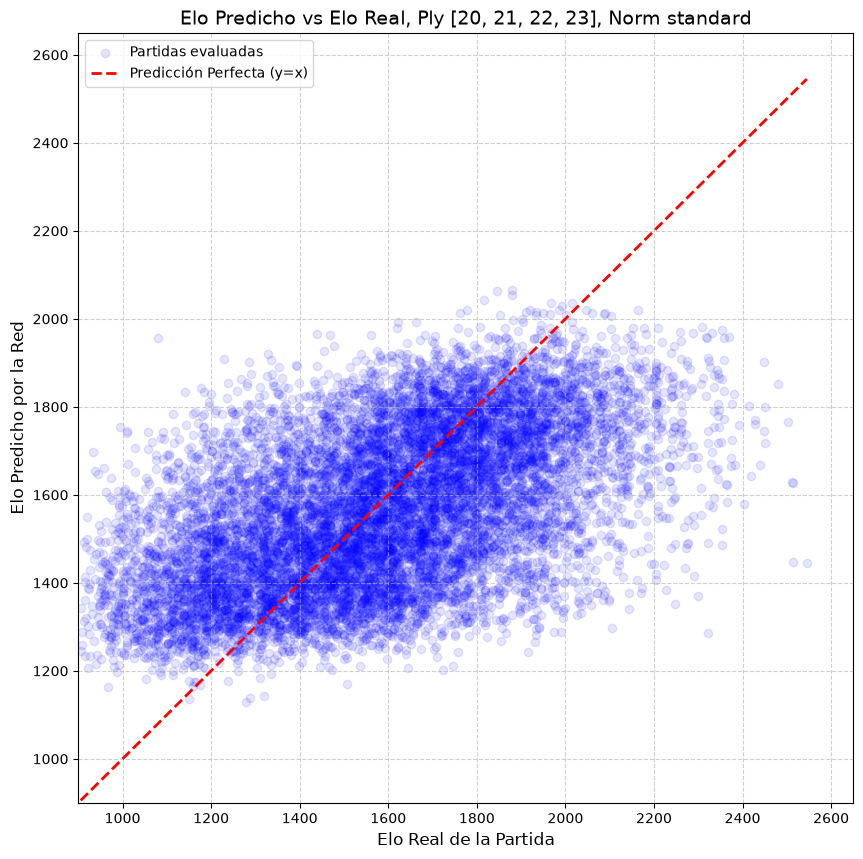

In [43]:
plt.figure(figsize=(10, 10))

plt.scatter(y_true_real, y_pred_real, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(y_true_real), min(y_pred_real))
max_val = max(max(y_true_real), max(y_pred_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Elo Predicho vs Elo Real, Ply {ply}, Norm {norm}', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()

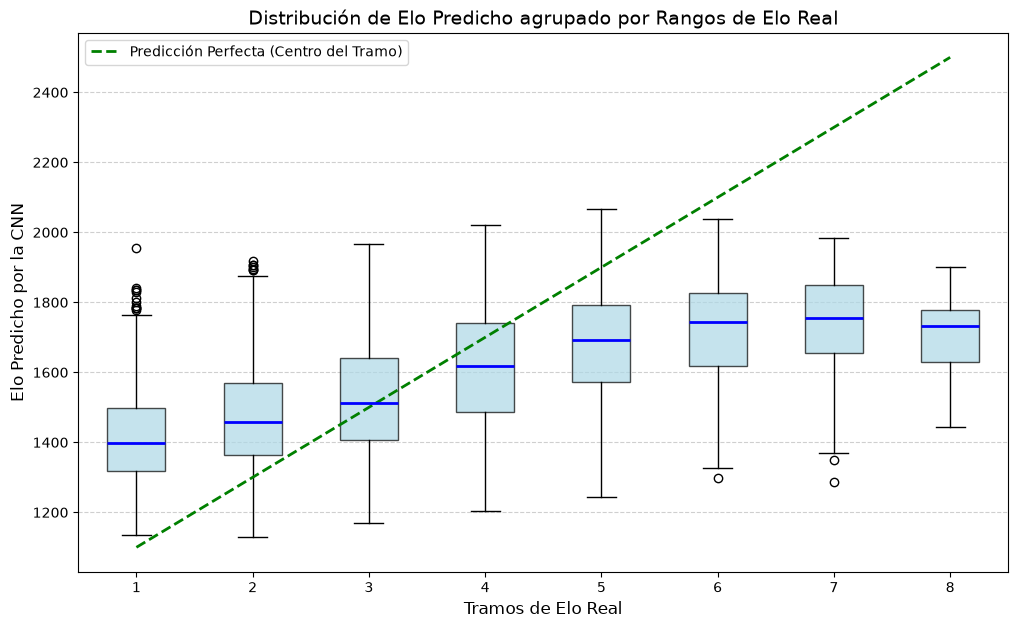

In [44]:
bins = np.arange(1000, 2601, 200) 
etiquetas_tramos = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# 2. Agrupar las predicciones en sus respectivas categorías
predicciones_por_tramo = []
medias_ideales = []

for i in range(len(bins)-1):
    limite_inferior = bins[i]
    limite_superior = bins[i+1]
    
    # Creamos una máscara para filtrar las partidas que caen en este tramo
    mascara = (y_true_real >= limite_inferior) & (y_true_real < limite_superior)
    
    # Guardamos las predicciones del modelo para esos jugadores
    predicciones_filtradas = y_pred_real[mascara]
    predicciones_por_tramo.append(predicciones_filtradas)
    
    # Guardamos el centro del tramo para dibujar la línea de "Perfección"
    medias_ideales.append((limite_inferior + limite_superior) / 2)

# 3. Dibujar el Box Plot
plt.figure(figsize=(12, 7))

# patch_artist=True permite colorear las cajas
bp = plt.boxplot(predicciones_por_tramo, patch_artist=True)

# Darle formato a los colores para que se vea académico
for box in bp['boxes']:
    box.set_facecolor('lightblue')
    box.set_alpha(0.7)
for median in bp['medians']:
    median.set(color='blue', linewidth=2) # La línea roja es la mediana de tu modelo

# 4. Añadir la "Línea Ideal"
# Si el modelo adivinara perfecto, las cajas estarían centradas en esta línea verde
x_pos = np.arange(1, len(etiquetas_tramos) + 1)
plt.plot(x_pos, medias_ideales, color='green', linestyle='--', linewidth=2, label='Predicción Perfecta (Centro del Tramo)')

plt.title('Distribución de Elo Predicho agrupado por Rangos de Elo Real', fontsize=14)
plt.xlabel('Tramos de Elo Real', fontsize=12)
plt.ylabel('Elo Predicho por la CNN', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.show()